# Plotting colour evolution for predicted sources

In [1]:
%matplotlib inline
# Static plots
#%matplotlib ipympl
# Interactive plots
import numpy as np
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as mpe
import matplotlib.patches as mpatches
from matplotlib import ticker as mticker
from matplotlib.collections import LineCollection
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from sklearn.model_selection import train_test_split
from astropy.visualization import LogStretch, PowerStretch
from astropy.visualization.mpl_normalize import ImageNormalize
from astropy.cosmology import Planck18 as cosmo
from astropy.stats import sigma_clip
# import pyccl as ccl
from astropy import units as u
from scipy.ndimage import gaussian_filter
from itertools import combinations
import colorcet as cc
import cmasher as cmr
import met_brewer
import pandas as pd
import global_variables as gv
import global_functions as gf

In [2]:
mpl.rcdefaults()
plt.rcParams['text.usetex'] = True

In [3]:
def colored_line(x, y, c, ax, **lc_kwargs):
    """
    Plot a line with a color specified along the line by a third value.

    It does this by creating a collection of line segments. Each line segment is
    made up of two straight lines each connecting the current (x, y) point to the
    midpoints of the lines connecting the current point with its two neighbors.
    This creates a smooth line with no gaps between the line segments.

    Parameters
    ----------
    x, y : array-like
        The horizontal and vertical coordinates of the data points.
    c : array-like
        The color values, which should be the same size as x and y.
    ax : Axes
        Axis object on which to plot the colored line.
    **lc_kwargs
        Any additional arguments to pass to matplotlib.collections.LineCollection
        constructor. This should not include the array keyword argument because
        that is set to the color argument. If provided, it will be overridden.

    Returns
    -------
    matplotlib.collections.LineCollection
        The generated line collection representing the colored line.
    """
    if "array" in lc_kwargs:
        warnings.warn('The provided "array" keyword argument will be overridden')

    # Default the capstyle to butt so that the line segments smoothly line up
    default_kwargs = {"capstyle": "butt"}
    default_kwargs.update(lc_kwargs)

    # Compute the midpoints of the line segments. Include the first and last points
    # twice so we don't need any special syntax later to handle them.
    x        = np.asarray(x)
    y        = np.asarray(y)
    x_midpts = np.hstack((x[0], 0.5 * (x[1:] + x[:-1]), x[-1]))
    y_midpts = np.hstack((y[0], 0.5 * (y[1:] + y[:-1]), y[-1]))

    # Determine the start, middle, and end coordinate pair of each line segment.
    # Use the reshape to add an extra dimension so each pair of points is in its
    # own list. Then concatenate them to create:
    # [
    #   [(x1_start, y1_start), (x1_mid, y1_mid), (x1_end, y1_end)],
    #   [(x2_start, y2_start), (x2_mid, y2_mid), (x2_end, y2_end)],
    #   ...
    # ]
    coord_start = np.column_stack((x_midpts[:-1], y_midpts[:-1]))[:, np.newaxis, :]
    coord_mid   = np.column_stack((x, y))[:, np.newaxis, :]
    coord_end   = np.column_stack((x_midpts[1:], y_midpts[1:]))[:, np.newaxis, :]
    segments    = np.concatenate((coord_start, coord_mid, coord_end), axis=1)

    lc = LineCollection(segments, **default_kwargs)
    lc.set_array(c)  # set the colors of each segment

    return ax.add_collection(lc)

In [4]:
def create_median_values(x, y, z, nbins=10, scale='log'):
    min_z = np.nanmin(z)
    max_z = np.nanmax(z)
    if scale == 'log':
        z_bins = np.logspace(np.log10(min_z), np.log10(max_z), nbins)
    elif scale == 'linear':
        z_bins = np.linspace(min_z, max_z, nbins)
    elif scale == 'inverselog':
        linear_space = np.linspace(0, 1, nbins)
        power  = 2
        z_bins = min_z + (max_z - min_z) * (linear_space ** power)
    med_x = []
    med_y = []
    med_z = []
    for count, z_bin in enumerate(z_bins[:-1]):
        filter_z = np.array(z >= z_bins[count]) & np.array(z < z_bins[count + 1])
        med_x.append(np.nanmedian(x[filter_z]))
        med_y.append(np.nanmedian(y[filter_z]))
        med_z.append(np.nanmedian(z[filter_z]))
    return med_x, med_y, med_z

In [5]:
def combine_predictions(df):
    pred_AGN_filter  = df['pred_class_cal'] == 1
    df['pred_radio'] = np.where(pred_AGN_filter, df['pred_radio_AGN_cal'], df['pred_radio_SFG_cal'])
    df['Prob_radio'] = np.where(pred_AGN_filter, df['Prob_radio_AGN'], df['Prob_radio_SFG'])
    df['pred_Z']     = np.where(pred_AGN_filter, df['pred_Z_rAGN'], df['pred_Z_rSFG'])
    return df

In [6]:
def create_colours(df, mag_list, mag_names_short_ver):
    colours_list = []
    for mags_pair in combinations(mag_list, 2):
        colour_name = mag_names_short_ver[mags_pair[0]] + '_' + mag_names_short_ver[mags_pair[1]]
        df[colour_name] = df[mags_pair[0]] - df[mags_pair[1]]
        colours_list.append(colour_name)
    return df, colours_list

In [7]:
colour_hex_SFG = '#1E88E5'
colour_hex_AGN = '#D32F2F'
black_hex      = '#000000'

colour_rSFG = mcolors.to_rgba(colour_hex_SFG)
colour_rAGN = mcolors.to_rgba(colour_hex_AGN)
colour_rSFG_shade = gf.create_shaded_colour(colour_hex_SFG)
colour_rAGN_shade = gf.create_shaded_colour(colour_hex_AGN)
colour_rSFG_rgb_darker, colour_rSFG_rgb_bright = gf.create_darker_brighter_rgb(colour_hex_SFG)
colour_rAGN_rgb_darker, colour_rAGN_rgb_bright = gf.create_darker_brighter_rgb(colour_hex_AGN)

cm_gradient_rAGN = mcolors.LinearSegmentedColormap.from_list('gradient_rAGN',
                                                             [colour_rAGN_rgb_darker,
                                                              colour_rAGN_rgb_bright], N=50)
cm_gradient_rSFG = mcolors.LinearSegmentedColormap.from_list('gradient_rGal',
                                                             [colour_rSFG_rgb_darker,
                                                              colour_rSFG_rgb_bright], N=50)
cm_gradient = {'rAGN': cm_gradient_rAGN, 'rSFG': cm_gradient_rSFG}

cm_gradient_AGN = gf.create_colour_gradient(colour_hex_AGN)
cm_gradient_SFG = gf.create_colour_gradient(colour_hex_SFG)
cm_grad_AGN_whi = gf.create_colour_gradient_to_white(colour_hex_AGN)
cm_grad_SFG_whi = gf.create_colour_gradient_to_white(colour_hex_SFG)

colour_black      = mcolors.to_rgba(black_hex)
cm_gradient_black = gf.create_colour_gradient(black_hex)

In [8]:
colour_ish = met_brewer.met_brew(name='Isfahan2', n=123, brew_type='continuous')
colour_ish_mpl = mcolors.LinearSegmentedColormap.from_list('Isfahan2', colour_ish, N=11)
cmap_hist2d_cats_SFG = colour_ish_mpl

In [9]:
save_plots  = False

In [10]:
use_imputed = False  # use (or not) imputed magnitudes and colours
if use_imputed:
    imputed_str = 'imputed'
elif not use_imputed:
    imputed_str = 'nonimputed'

In [11]:
used_sample = 'all'  # 'all', 'test', 'unknown'

In [12]:
file_HETDEX_all  = gv.preds_path + 'HETDEX_full_prediction.parquet'
file_HETDEX_test = gv.preds_path + 'HETDEX_Test_prediction.parquet'
file_HETDEX_unk  = gv.preds_path + 'HETDEX_Unknown_prediction.parquet'
files_HETDEX     = {'all': file_HETDEX_all, 'test': file_HETDEX_test, 'unknown': file_HETDEX_unk}

In [13]:
data_catalog_HETDEX_df = pd.read_parquet(files_HETDEX[used_sample], engine='fastparquet')

In [14]:
data_catalog_HETDEX_df = combine_predictions(data_catalog_HETDEX_df)

In [15]:
file_HETDEX_nonimp_mags = gv.preds_path + 'HETDEX_mags_non_imputed.parquet'

In [16]:
data_nonimp_mags        = pd.read_parquet(file_HETDEX_nonimp_mags, engine='fastparquet')

Replace mags with non-imp versions

In [17]:
data_idx  = data_catalog_HETDEX_df.index
mags_cols = data_nonimp_mags.columns
data_catalog_HETDEX_df.loc[data_idx, mags_cols] = data_nonimp_mags.loc[data_idx, mags_cols]

Re-calculate colours with non-imp magnitudes

In [18]:
mag_names_short      = {'gmag': 'g', 'rmag': 'r', 'imag': 'i', 'zmag': 'z',
                        'ymag': 'y', 'Jmag': 'J', 'Hmag': 'H', 'Kmag': 'K',
                        'W1mproPM': 'W1', 'W2mproPM': 'W2',
                        'W3mag': 'W3', 'W4mag': 'W4'}

In [19]:
data_catalog_HETDEX_df, colours_list = create_colours(data_catalog_HETDEX_df,
                                                      mags_cols,
                                                      mag_names_short)

In [20]:
np.shape(data_catalog_HETDEX_df)

(15136878, 104)

In [21]:
data_catalog_HETDEX_df.columns.values

array(['RA_ICRS', 'DE_ICRS', 'Name', 'TYPE', 'Z', 'band_num',
       'Sint_LOFAR', 'Sint_LOFAR_non_imp', 'rms_LOFAR', 'Speak_LOFAR',
       'Speak_LOFAR_non_imp', 'W1mproPM', 'W2mproPM', 'gmag', 'rmag',
       'imag', 'zmag', 'ymag', 'W3mag', 'W4mag', 'Jmag', 'Hmag', 'Kmag',
       'g_r', 'g_i', 'g_z', 'g_y', 'g_J', 'g_H', 'g_K', 'g_W1', 'g_W2',
       'g_W3', 'g_W4', 'r_i', 'r_z', 'r_y', 'r_J', 'r_H', 'r_K', 'r_W1',
       'r_W2', 'r_W3', 'r_W4', 'i_z', 'i_y', 'i_J', 'i_H', 'i_K', 'i_W1',
       'i_W2', 'i_W3', 'i_W4', 'z_y', 'z_J', 'z_H', 'z_K', 'z_W1', 'z_W2',
       'z_W3', 'z_W4', 'y_J', 'y_H', 'y_K', 'y_W1', 'y_W2', 'y_W3',
       'y_W4', 'J_H', 'J_K', 'J_W1', 'J_W2', 'J_W3', 'J_W4', 'H_K',
       'H_W1', 'H_W2', 'H_W3', 'H_W4', 'K_W1', 'K_W2', 'K_W3', 'K_W4',
       'W1_W2', 'W1_W3', 'W1_W4', 'W2_W3', 'W2_W4', 'W3_W4',
       'radio_detect', 'LOFAR_detect', 'class', 'Prob_AGN',
       'pred_class_cal', 'Prob_radio_AGN', 'pred_radio_AGN_cal',
       'Prob_radio_SFG', 'pred_radio_

In [22]:
mask_pred_AGN       = np.array(data_catalog_HETDEX_df.loc[:, 'pred_class_cal'] == 1)
mask_pred_SFG       = np.array(data_catalog_HETDEX_df.loc[:, 'pred_class_cal'] == 0)
mask_pred_radio_AGN = np.array(data_catalog_HETDEX_df.loc[:, 'pred_radio_AGN_cal'] == 1)
mask_pred_radio_SFG = np.array(data_catalog_HETDEX_df.loc[:, 'pred_radio_SFG_cal'] == 1)
mask_pred_radio     = np.array(data_catalog_HETDEX_df.loc[:, 'pred_radio'] == 1)
mask_pred_rAGN      = mask_pred_AGN & mask_pred_radio_AGN
mask_pred_rSFG      = mask_pred_SFG & mask_pred_radio_SFG

if used_sample != 'unknown':
    mask_true_AGN       = np.array(data_catalog_HETDEX_df.loc[:, 'class'] == 1)
    mask_true_SFG       = np.array(data_catalog_HETDEX_df.loc[:, 'class'] == 0)
    mask_true_radio     = np.array(data_catalog_HETDEX_df.loc[:, 'LOFAR_detect'] == 1)
    mask_true_rAGN      = mask_true_AGN & mask_true_radio
    mask_true_rSFG      = mask_true_SFG & mask_true_radio
    mask_good_true_z    = np.array(data_catalog_HETDEX_df.loc[:, 'Z'] > 0)

In [23]:
print(f'Subset has {len(data_catalog_HETDEX_df):,.0f} sources')
print(f'Out of {len(data_catalog_HETDEX_df):,.0f}, {np.sum(mask_pred_SFG):,.0f} sources predicted as SFGs')
print(f'Out of {np.sum(mask_pred_SFG):,.0f}, {np.sum(mask_pred_rSFG):,.0f} sources predicted as radio detectable')

Subset has 15,136,878 sources
Out of 15,136,878, 5,110,083 sources predicted as SFGs
Out of 5,110,083, 163,272 sources predicted as radio detectable


y-j vs H-K, most relevant redshift SHAP drivers for SFGs

If needed, omit all imputed magnitudes and colours.

In [24]:
mag_cols_lim_5sigma = {'W1mproPM': 20.13, 'W2mproPM': 19.81, 'Sint_LOFAR_AB': 17.52,
                       'Total_flux_VLASS_AB': 15.21, 'TotalFlux_LoLSS_AB': 12.91,
                       'Stotal_TGSS_AB': 11.18, 'Fint_VLAS82_AB': 17.86,
                       'Flux_COSMOSVLA3_AB': 21.25, 'W1mag': 19.6, 'W2mag': 19.34,
                       'W3mag': 16.67, 'W4mag': 14.62, 'gmag': 23.3, 'rmag': 23.2,
                       'imag': 23.1, 'zmag': 22.3, 'ymag': 21.4, 'FUVmag': 20.0,
                       'NUVmag': 21.0, 'FEP': 57.9, 'Jmag': 17.45, 'Hmag': 17.24,
                       'Kmag': 16.59}  # 5-sigma limits
mags_to_impute      = ['W1mproPM', 'W2mproPM', 'gmag', 'rmag', 'imag', 'zmag',
                       'ymag', 'Jmag', 'Hmag', 'Kmag', 'W3mag', 'W4mag']
mag_names_short     = {'gmag': 'g', 'rmag': 'r', 'imag': 'i', 'zmag': 'z',
                       'ymag': 'y', 'Jmag': 'J', 'Hmag': 'H', 'Kmag': 'K',
                       'W1mproPM': 'W1', 'W2mproPM': 'W2', 'W3mag': 'W3',
                       'W4mag': 'W4'}

In [25]:
#if not use_imputed:
#    for mag in mags_to_impute:
#        faint_filter = np.array(data_catalog_HETDEX_df.loc[:, mag] >= mag_cols_lim_5sigma[mag])
#        data_catalog_HETDEX_df.loc[faint_filter, mag] = np.nan

In [26]:
#if not use_imputed:
#    from itertools import combinations
#    for mags_pair in combinations(mags_to_impute, 2):
#        colour_name             = mag_names_short[mags_pair[0]] + '_' + mag_names_short[mags_pair[1]]
#        data_catalog_HETDEX_df[colour_name] = data_catalog_HETDEX_df[mags_pair[0]] - data_catalog_HETDEX_df[mags_pair[1]]

In [27]:
data_catalog_HETDEX_df.loc[mask_pred_rSFG, ['Prob_radio_SFG', 'pred_Z_rSFG', 'band_num']].describe()

,Prob_radio_SFG,pred_Z_rSFG,band_num
count,163272.000000,163272.000000,163272.000000
mean,0.383042,0.420520,7.679186
std,0.208215,0.296174,3.647542
min,0.199572,0.007900,2.000000
25%,0.237353,0.186800,4.000000
50%,0.293236,0.347100,9.000000
75%,0.439742,0.567300,12.000000
max,0.929218,1.502200,12.000000


In [32]:
display(data_catalog_HETDEX_df.loc[mask_pred_radio & mask_pred_AGN,
    ['g_r', 'r_i', 'y_J', 'H_K', 'W1_W2', 'W1_W3', 'W3_W4']].describe())
display(data_catalog_HETDEX_df.loc[mask_pred_radio & mask_pred_SFG,
    ['g_r', 'r_i', 'y_J', 'H_K', 'W1_W2', 'W1_W3', 'W3_W4']].describe())

,g_r,r_i,y_J,H_K,W1_W2,W1_W3,W3_W4
count,58355.000000,63975.000000,7616.000000,7900.000000,98483.000000,77314.000000,77311.000000
mean,0.550416,0.315235,0.570259,-0.037899,-0.022149,1.545021,1.525073
std,0.442703,0.386151,0.529488,0.352660,0.453120,0.976882,0.718100
min,-6.387100,-6.473100,-1.833500,-1.934000,-2.244001,-3.139000,-2.061000
25%,0.287199,0.126499,0.040001,-0.379000,-0.239000,1.250999,1.113001
50%,0.550200,0.317900,0.627900,-0.055000,-0.043001,1.657999,1.592999
75%,0.834000,0.494000,0.898376,0.226000,0.249001,2.040998,2.049999
max,5.087000,4.648201,4.091101,1.831999,4.163000,5.811999,4.460999


,g_r,r_i,y_J,H_K,W1_W2,W1_W3,W3_W4
count,96132.000000,108849.000000,45722.000000,47870.000000,163271.000000,120786.000000,120781.000000
mean,0.807840,0.563973,0.580307,-0.057166,-0.359743,0.481479,1.218134
std,0.383221,0.371103,0.411830,0.294597,0.184709,1.499051,0.873162
min,-5.644599,-4.769900,-4.893001,-2.274000,-4.845000,-3.082000,-3.130000
25%,0.577599,0.351599,0.254500,-0.273000,-0.489000,-0.092001,0.719000
50%,0.808500,0.493502,0.583849,-0.138000,-0.346999,0.986000,1.334999
75%,1.111825,0.692499,0.887500,0.144001,-0.240000,1.564001,1.869001
max,7.693300,5.909901,4.828200,1.916000,1.713999,7.132999,4.007000


Plotting for 98483 predicted radio AGN
Plotting for 163272 predicted radio non-AGN


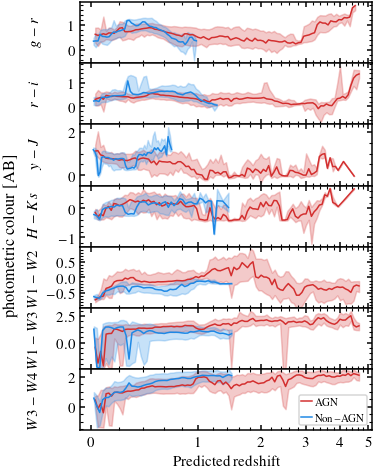

In [57]:
base_size, rc_tmp = gf.set_aaasize('column', aspect=1.35, fraction=1.0)  # 'text' or 'column' or 'halfcolumn'

def fmt_orig_redshift(x, pos):
        return rf'${x - 1:.0f}$'

with mpl.rc_context(rc_tmp):
    fig, axes = plt.subplots(nrows=7, ncols=1, width_ratios=[1],
                             height_ratios=[1] * 7,
                             figsize=base_size, layout='compressed',
                             sharex='all', sharey='none',
                             gridspec_kw={'wspace': 0, 'hspace': 0})
    axes_flat = axes.flatten()
    axes_flat[0].set_xscale('log')

    col_x        = 'pred_Z'
    cols_y       = ['g_r', 'r_i', 'y_J', 'H_K', 'W1_W2', 'W1_W3', 'W3_W4']
    clx_label    = r'$\mathrm{Predicted ~ redshift}$'
    cly_labels   = [r'${g} - {r}$',
                    r'${r} - {i}$',
                    r'${y} - {J}$',
                    r'${H} - {Ks}$',
                    r'${W1} - {W2}$',
                    r'${W1} - {W3}$',
                    r'${W3} - {W4}$']
    
    filter_pred_AGN_r = mask_pred_radio & mask_pred_AGN  # mask_true_radio & 
    filter_pred_SFG_r = mask_pred_radio & mask_pred_SFG
    #filter_pred_r     = [mask_pred_SFG_r, mask_pred_AGN_r]
    print(f'Plotting for {np.sum(filter_pred_AGN_r)} predicted radio AGN')
    print(f'Plotting for {np.sum(filter_pred_SFG_r)} predicted radio non-AGN')

    x_data_AGN   = 1 + data_catalog_HETDEX_df.loc[filter_pred_AGN_r, col_x].to_numpy()
    x_data_SFG   = 1 + data_catalog_HETDEX_df.loc[filter_pred_SFG_r, col_x].to_numpy()
    num_used_AGN = np.sum(np.isfinite(x_data_AGN))
    num_used_SFG = np.sum(np.isfinite(x_data_SFG))
    n_bins_AGN   = min(98, int(num_used_AGN * 0.001))
    n_bins_SFG   = min(48, int(num_used_SFG * 0.0005))

    for ax_tmp, col_y, cly_label in zip(axes_flat, cols_y, cly_labels):
        y_data_AGN = data_catalog_HETDEX_df.loc[filter_pred_AGN_r, col_y].to_numpy()
        y_data_SFG = data_catalog_HETDEX_df.loc[filter_pred_SFG_r, col_y].to_numpy()
    
        # AGN
        bx_AGN, med_AGN, lo_AGN, hi_AGN = gf.binned_median_and_scatter(x_data_AGN,
                                                                       y_data_AGN,
                                                                       nbins=n_bins_AGN,
                                                                       scale='log')
        valid_AGN = np.isfinite(med_AGN)
        ax_tmp.plot(bx_AGN[valid_AGN],
                    med_AGN[valid_AGN],
                    color=colour_hex_AGN,
                    label=r'$\mathrm{AGN}$')
        ax_tmp.fill_between(bx_AGN[valid_AGN],
                            lo_AGN[valid_AGN],
                            hi_AGN[valid_AGN],
                            color=colour_hex_AGN,
                            alpha=0.25)
    
        # SFG
        bx_SFG, med_SFG, lo_SFG, hi_SFG = gf.binned_median_and_scatter(x_data_SFG,
                                                                       y_data_SFG,
                                                                       nbins=n_bins_SFG,
                                                                       scale='log')
        valid_SFG = np.isfinite(med_SFG)
        ax_tmp.plot(bx_SFG[valid_SFG],
                    med_SFG[valid_SFG],
                    color=colour_hex_SFG,
                    label=r'$\mathrm{Non{-}AGN}$')
        ax_tmp.fill_between(bx_SFG[valid_SFG],
                            lo_SFG[valid_SFG],
                            hi_SFG[valid_SFG],
                            color=colour_hex_SFG,
                            alpha=0.25)

        ax_tmp.set_ylabel(cly_label)

        minor_ticks = np.concatenate([np.arange(n + 0.2, n + 0.9, 0.2) for n in range(1, 6)])

        ax_tmp.minorticks_on()
        ax_tmp.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_orig_redshift))
        ax_tmp.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
        ax_tmp.xaxis.set_minor_locator(mticker.FixedLocator(minor_ticks))
        ax_tmp.xaxis.set_minor_formatter(plt.NullFormatter())

    axes_flat[-1].set_xlabel(clx_label)
    
    axes_flat[-1].legend(loc=4, handletextpad=0.3, handlelength=1., borderpad=0.2)
    # Fix axes limits (ad-hoc)
    axes_flat[4].set_ylim(bottom=-0.99, top=0.99)
    axes_flat[5].set_ylim(bottom=-2.49)
    axes_flat[6].set_ylim(top=2.49)

    fig.align_ylabels(axes_flat)
    fig.supylabel(r'$\mathrm{photometric ~ colour}\, \mathrm{[AB]}$', x=-0.07)

    if save_plots:
        plt.savefig(gv.plots_path + f'colours_vs_pred_z_evol_pred_radio_AGN_SFG_HETDEX.pdf', bbox_inches='tight')
    plt.show()

Plotting for 10026795 predicted radio AGN
Plotting for 5110083 predicted radio non-AGN


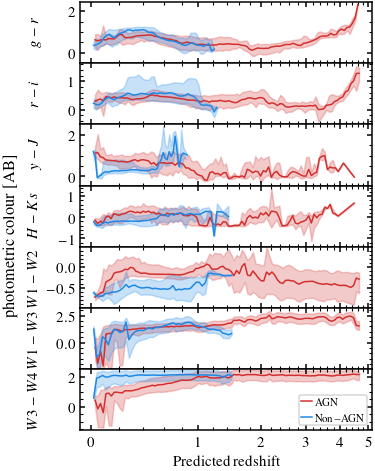

In [56]:
base_size, rc_tmp = gf.set_aaasize('column', aspect=1.35, fraction=1.0)  # 'text' or 'column' or 'halfcolumn'

def fmt_orig_redshift(x, pos):
        return rf'${x - 1:.0f}$'

with mpl.rc_context(rc_tmp):
    fig, axes = plt.subplots(nrows=7, ncols=1, width_ratios=[1],
                             height_ratios=[1] * 7,
                             figsize=base_size, layout='compressed',
                             sharex='all', sharey='none',
                             gridspec_kw={'wspace': 0, 'hspace': 0})
    axes_flat = axes.flatten()
    axes_flat[0].set_xscale('log')

    col_x        = 'pred_Z'
    cols_y       = ['g_r', 'r_i', 'y_J', 'H_K', 'W1_W2', 'W1_W3', 'W3_W4']
    clx_label    = r'$\mathrm{Predicted ~ redshift}$'
    cly_labels   = [r'${g} - {r}$',
                    r'${r} - {i}$',
                    r'${y} - {J}$',
                    r'${H} - {Ks}$',
                    r'${W1} - {W2}$',
                    r'${W1} - {W3}$',
                    r'${W3} - {W4}$']
    
    filter_pred_AGN_r = mask_pred_AGN  # mask_true_radio & 
    filter_pred_SFG_r = mask_pred_SFG
    #filter_pred_r     = [mask_pred_SFG_r, mask_pred_AGN_r]
    print(f'Plotting for {np.sum(filter_pred_AGN_r)} predicted radio AGN')
    print(f'Plotting for {np.sum(filter_pred_SFG_r)} predicted radio non-AGN')

    
    x_data_AGN   = 1 + data_catalog_HETDEX_df.loc[filter_pred_AGN_r, col_x].to_numpy()
    x_data_SFG   = 1 + data_catalog_HETDEX_df.loc[filter_pred_SFG_r, col_x].to_numpy()
    num_used_AGN = np.sum(np.isfinite(x_data_AGN))
    num_used_SFG = np.sum(np.isfinite(x_data_SFG))
    n_bins_AGN   = min(98, int(num_used_AGN * 0.001))
    n_bins_SFG   = min(48, int(num_used_SFG * 0.0005))

    for ax_tmp, col_y, cly_label in zip(axes_flat, cols_y, cly_labels):
        y_data_AGN = data_catalog_HETDEX_df.loc[filter_pred_AGN_r, col_y].to_numpy()
        y_data_SFG = data_catalog_HETDEX_df.loc[filter_pred_SFG_r, col_y].to_numpy()
    
        # AGN
        bx_AGN, med_AGN, lo_AGN, hi_AGN = gf.binned_median_and_scatter(x_data_AGN,
                                                                       y_data_AGN,
                                                                       nbins=n_bins_AGN,
                                                                       scale='log')
        valid_AGN = np.isfinite(med_AGN)
        ax_tmp.plot(bx_AGN[valid_AGN],
                    med_AGN[valid_AGN],
                    color=colour_hex_AGN,
                    label=r'$\mathrm{AGN}$')
        ax_tmp.fill_between(bx_AGN[valid_AGN],
                            lo_AGN[valid_AGN],
                            hi_AGN[valid_AGN],
                            color=colour_hex_AGN,
                            alpha=0.25)
    
        # SFG
        bx_SFG, med_SFG, lo_SFG, hi_SFG = gf.binned_median_and_scatter(x_data_SFG,
                                                                       y_data_SFG,
                                                                       nbins=n_bins_SFG,
                                                                       scale='log')
        valid_SFG = np.isfinite(med_SFG)
        ax_tmp.plot(bx_SFG[valid_SFG],
                    med_SFG[valid_SFG],
                    color=colour_hex_SFG,
                    label=r'$\mathrm{Non{-}AGN}$')
        ax_tmp.fill_between(bx_SFG[valid_SFG],
                            lo_SFG[valid_SFG],
                            hi_SFG[valid_SFG],
                            color=colour_hex_SFG,
                            alpha=0.25)

        ax_tmp.set_ylabel(cly_label)

        minor_ticks = np.concatenate([np.arange(n + 0.2, n + 0.9, 0.2) for n in range(1, 6)])

        ax_tmp.minorticks_on()
        ax_tmp.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_orig_redshift))
        ax_tmp.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
        ax_tmp.xaxis.set_minor_locator(mticker.FixedLocator(minor_ticks))
        ax_tmp.xaxis.set_minor_formatter(plt.NullFormatter())

    axes_flat[-1].set_xlabel(clx_label)
    
    axes_flat[-1].legend(loc=4, handletextpad=0.3, handlelength=1., borderpad=0.2)
    # Fix axes limits (ad-hoc)
    axes_flat[0].set_ylim(bottom=-0.5)
    axes_flat[2].set_ylim(top=2.49)
    axes_flat[3].set_ylim(bottom=-1.4)
    axes_flat[4].set_ylim(top=0.49)
    axes_flat[5].set_ylim(bottom=-2.49)
    axes_flat[6].set_ylim(top=2.49)

    fig.align_ylabels(axes_flat)
    fig.supylabel(r'$\mathrm{photometric ~ colour}\, \mathrm{[AB]}$', x=-0.07)

    if save_plots:
        plt.savefig(gv.plots_path + f'colours_vs_pred_z_evol_pred_AGN_SFG_HETDEX.pdf', bbox_inches='tight')
    plt.show()